# Laboratorio 01 - Cotizaciones Optimas de un Formador de Mercado
### Modelo de Copeland y Galai (1983) - Equipo 9

Este notebook es **solo de importaciones y visualizacion**. Toda la logica matematica y de simulacion vive en `src/` (`model.py`, `simulation.py`, `plots.py`). Semilla aleatoria fija: `np.random.seed(42)`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.model import optimize_quotes, S0, PI_I, PI_L
from src.simulation import simulate_trades, run_monte_carlo, get_regimes
from src.plots import generate_all_figures

np.random.seed(42)

## 1. Optimizacion de cotizaciones

In [2]:
A_opt, B_opt, spread_opt, utility_opt = optimize_quotes(pi_I=PI_I)
print(f"S0 = {S0:.2f}")
print(f"A* = {A_opt:.2f}")
print(f"B* = {B_opt:.2f}")
print(f"Spread* = {spread_opt:.2f}")
print(f"Utilidad esperada por trade = {utility_opt:.4f}")

S0 = 19.90
A* = 23.43
B* = 16.45
Spread* = 6.98
Utilidad esperada por trade = 0.8403


## 2. Simulacion de 10,000 trades y Monte Carlo (1,000 x 1,000) por regimen

In [3]:
sim_out = generate_all_figures(A_opt, B_opt, mc_n_runs=1000, mc_trades_per_run=1000, n_trades_path=10000)

for name, (a, b) in sim_out["regimes"].items():
    df = sim_out["paths"][name]
    res = sim_out["mc_results"][name]
    print(f"{name:10s} Bid={b:6.2f} Ask={a:6.2f} Spread={a-b:6.2f} | "
          f"PnL(10k trades)={df['cum_pnl'].iloc[-1]:9.2f} | "
          f"MC mean={res['mean_pnl']:8.2f} std={res['std_pnl']:7.2f} P(loss)={res['prob_loss']*100:5.1f}%")

Optimo     Bid= 16.45 Ask= 23.43 Spread=  6.98 | PnL(10k trades)=  8376.87 | MC mean=  840.89 std=  54.12 P(loss)=  0.0%
Estrecho   Bid= 19.75 Ask= 20.05 Spread=  0.30 | PnL(10k trades)= -6766.82 | MC mean= -675.26 std=  45.42 P(loss)=100.0%
Amplio     Bid= 18.40 Ask= 21.40 Spread=  3.00 | PnL(10k trades)=  3246.05 | MC mean=  326.22 std=  44.60 P(loss)=  0.0%


## 3. Figura 1 - Probabilidad de ejecucion vs. Spread

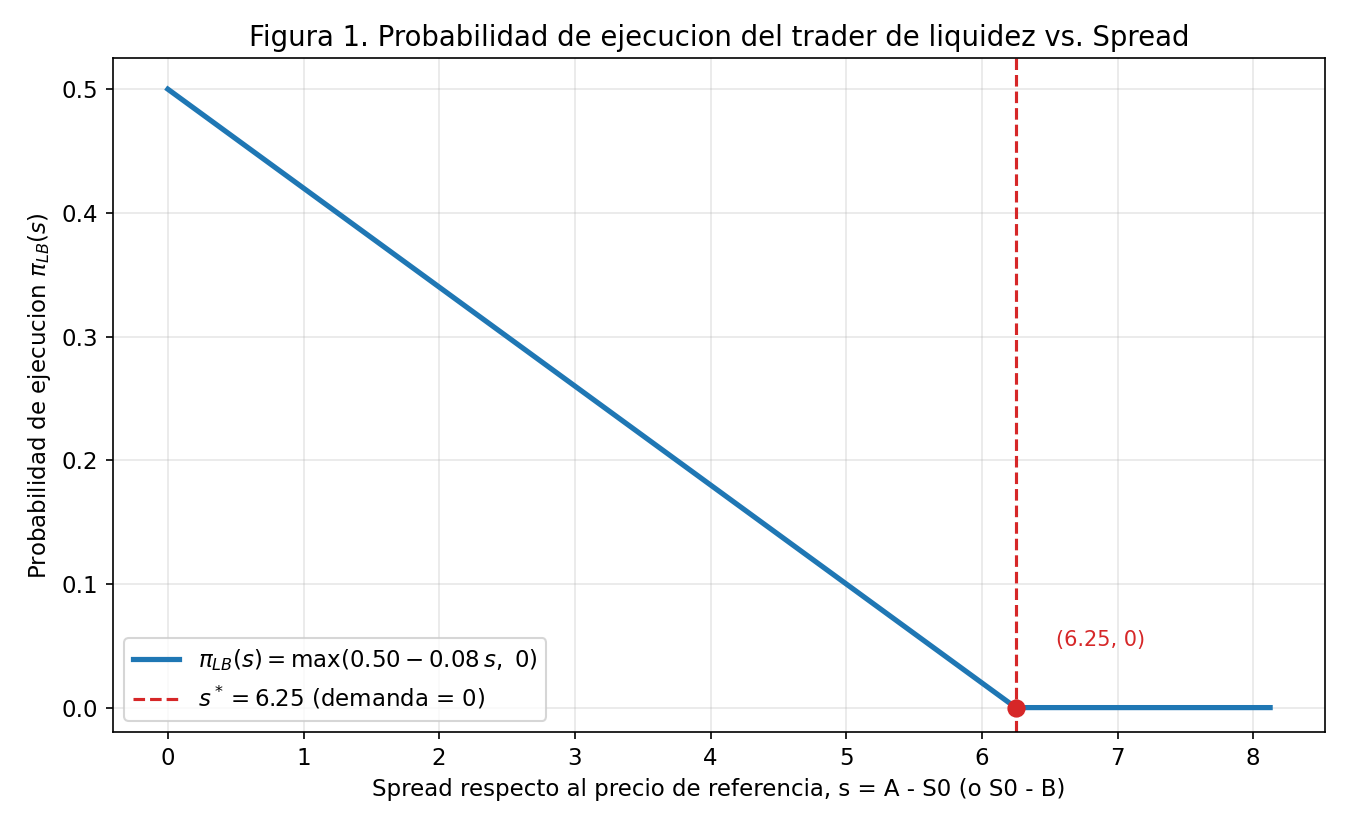

In [4]:
display(Image(filename=sim_out["figures"]["execution_probability"]))

## 4. Figura 2 - P&L acumulado (10,000 trades) por regimen

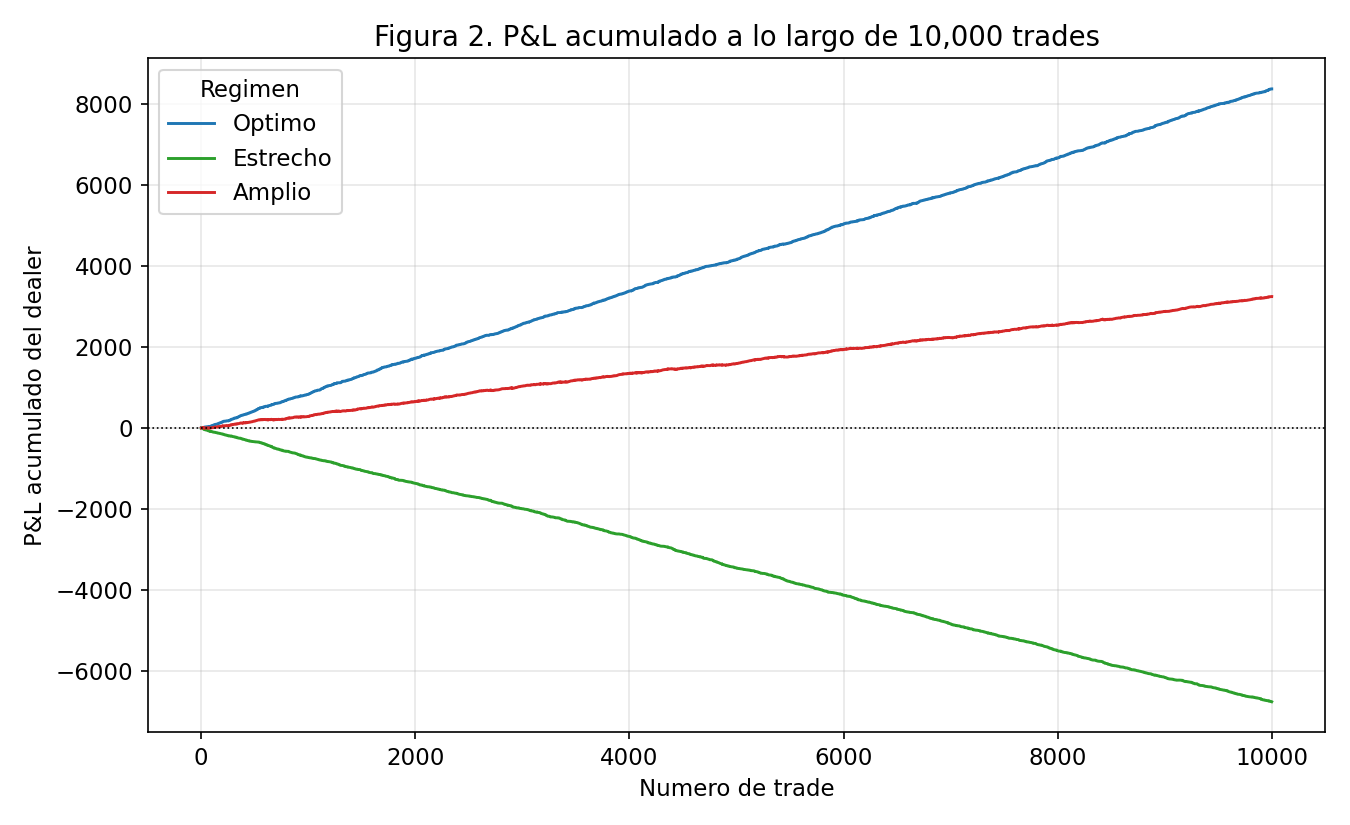

In [5]:
display(Image(filename=sim_out["figures"]["cumulative_pnl"]))

## 5. Figura 3 - Inventario acumulado (10,000 trades) por regimen

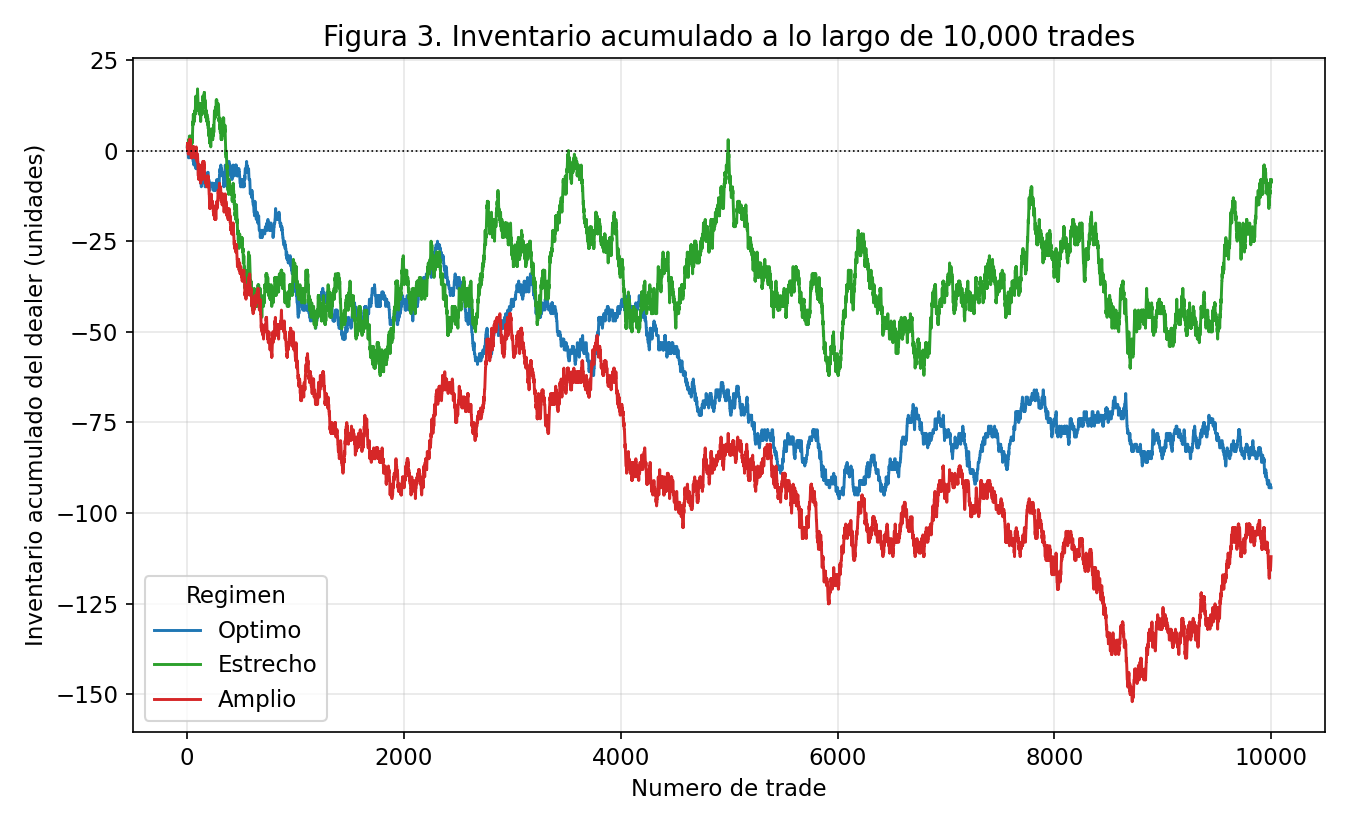

In [6]:
display(Image(filename=sim_out["figures"]["cumulative_inventory"]))

## 6. Figura 4 - Histograma Monte Carlo del P&L final

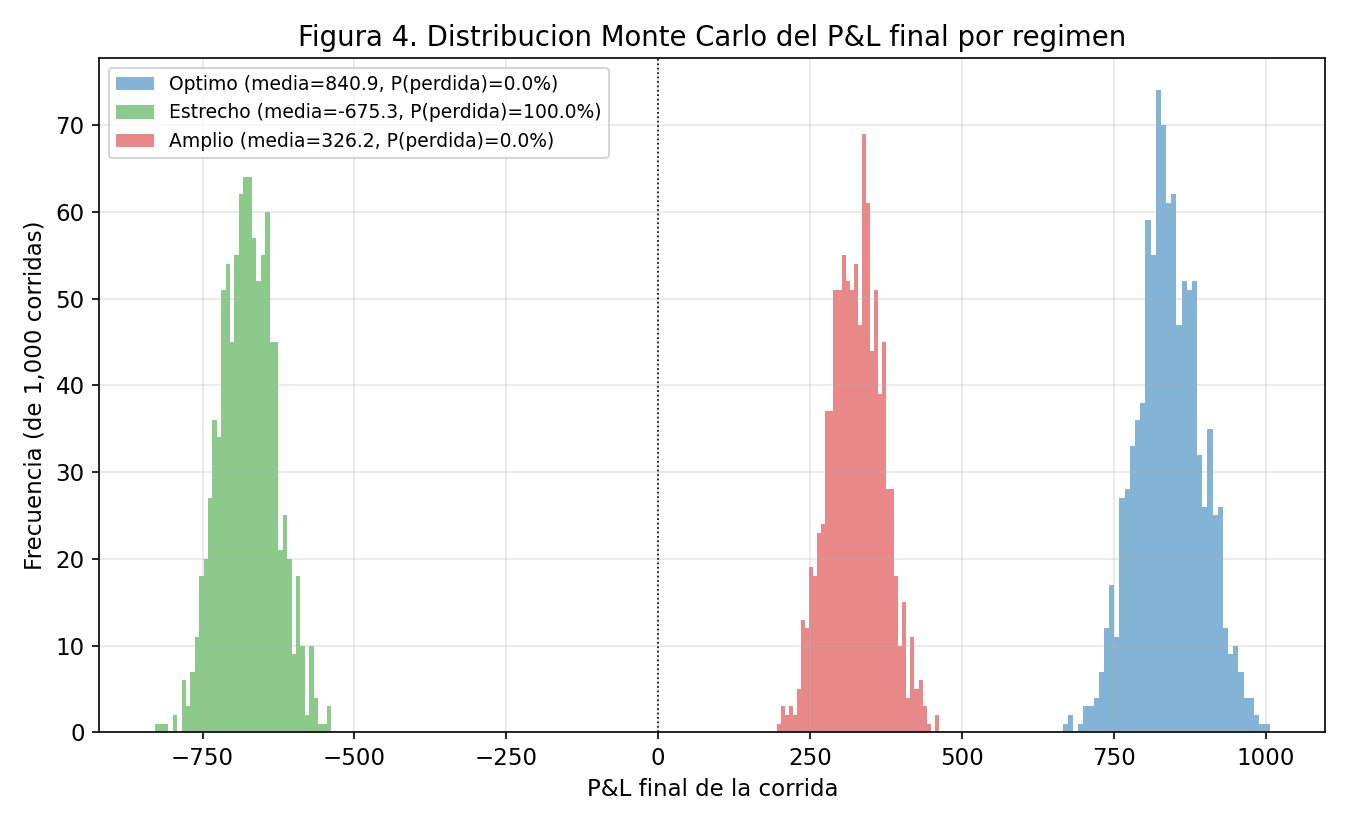

In [7]:
display(Image(filename=sim_out["figures"]["mc_histogram"]))

## 7. Figura 5 - Sensibilidad del Spread Optimo vs. pi_I

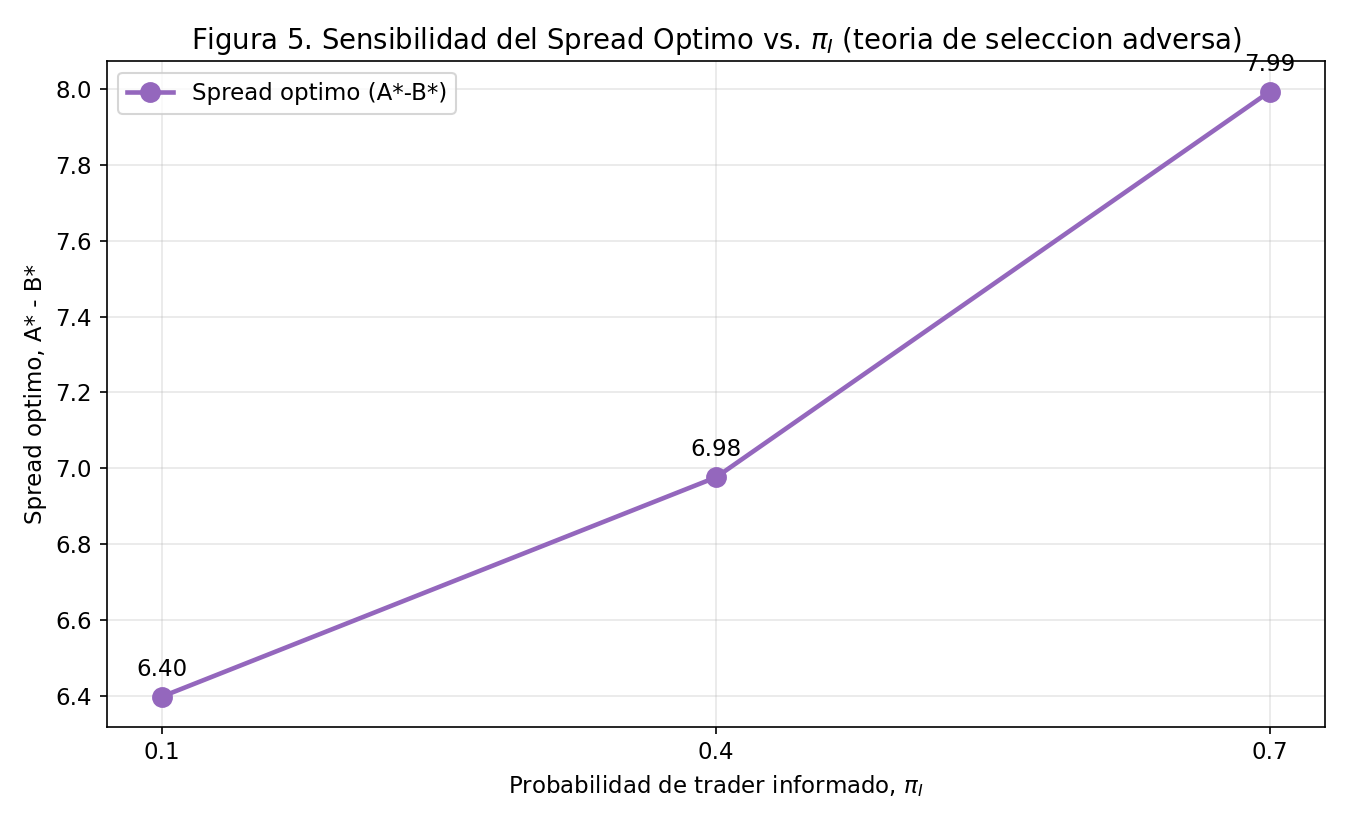

pi_I=0.1 -> spread optimo=6.40
pi_I=0.4 -> spread optimo=6.98
pi_I=0.7 -> spread optimo=7.99


In [8]:
display(Image(filename=sim_out["figures"]["spread_sensitivity"]))
for pi, s in zip(sim_out["sensitivity_pi"], sim_out["sensitivity_spreads"]):
    print(f"pi_I={pi:.1f} -> spread optimo={s:.2f}")